In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from utils import json_to_df, read_jsons, inject_prompt_type

In [ ]:
BASE_PATH = "../../results/sbrc/cifar10/exp2-models/{prompt_type}/{model_name}/{selection_algorithm}"

In [70]:
MODELS_NAME = ["qwen3:8b", "llama3.2:3b", "llama3.1:8b"]
PROMPTS_TYPE = ['cot', 'description', 'fewshot']
SELECTION_ALGORTIHM = ['poc', 'oort', 'random']

In [71]:
dfs = []
for mn in MODELS_NAME:
    for sa in SELECTION_ALGORTIHM:
        for pt in PROMPTS_TYPE:
            js_list = read_jsons(BASE_PATH.format(prompt_type=pt, model_name=mn, selection_algorithm=sa))
            if len(js_list)>0:
                df = pd.concat([inject_prompt_type(json_to_df(js), pt) for js in js_list])
                dfs.append(df)

In [72]:
data = pd.concat(dfs)

In [73]:
data.head()

,train_accuracy,train_loss,train_dataset_size,stat_util,training_time,prev_train_accuracy,prev_train_loss,prev_eval_loss,prev_eval_accuracy,last_round,...,utility,round,selection_method,selection_algorithm,selected,delay,llm_model_name,run_id,sample_time,prompt_type
0,0.40,51.27,1120,1997.128,1.958515,0.0,0.0,0.0,0.0,1,...,1997.128,1,k-agent,all-clients,True,False,qwen3:8b,0,0.000072,chain-of-thought
1,0.54,41.24,1727,2942.536,2.520432,0.0,0.0,0.0,0.0,1,...,2942.536,1,k-agent,all-clients,True,False,qwen3:8b,0,0.000072,chain-of-thought
2,0.49,49.66,1788,3287.873,2.782096,0.0,0.0,0.0,0.0,1,...,3287.873,1,k-agent,all-clients,True,False,qwen3:8b,0,0.000072,chain-of-thought
3,0.69,33.18,1656,2336.696,2.560945,0.0,0.0,0.0,0.0,1,...,2336.696,1,k-agent,all-clients,True,False,qwen3:8b,0,0.000072,chain-of-thought
4,0.58,49.58,927,1651.507,1.723653,0.0,0.0,0.0,0.0,1,...,1651.507,1,k-agent,all-clients,True,False,qwen3:8b,0,0.000072,chain-of-thought


In [74]:
data['hue_column'] = data['prompt_type'] +'-'+ data['selection_algorithm'] +'-'+ data['llm_model_name']
data = data.loc[data['round'] > 1].sort_values('hue_column')

In [75]:
BASE_PATH = "/home/rafael.jarczewski/selection-agent/results/sbrc/cifar10/exp1-literatura/{selection_algorithm}/{sample_size}"

In [76]:
SELECTION_ALGORTIHM = ['poc', 'oort', 'random', 'rrobin']
SAMPLE_SIZES = [15, 10, 5, 'rnd']

In [77]:
dfs = []
for sa in SELECTION_ALGORTIHM:
    for ssize in SAMPLE_SIZES:
        js_list = read_jsons(BASE_PATH.format(selection_algorithm=sa, sample_size=ssize))
        if len(js_list) > 0:
            df = pd.concat([json_to_df(js) for js in js_list])
            df['sample_size'] = str(ssize)
            dfs.append(df)

In [78]:
literatura = pd.concat(dfs)

In [79]:
literatura['hue_column'] = literatura['selection_algorithm'] +'-'+literatura['sample_size']
literatura = literatura.loc[literatura['round'] > 1].sort_values('hue_column')

In [80]:
mask1 = data['hue_column'].apply(lambda x: 'chain-of-thought-poc-llama3.1' in x)
mask2 = literatura['hue_column'].apply(lambda x: 'poc-5' in x)

In [81]:
d1 = data[mask1]
d2 = literatura[mask2]

In [82]:
df = pd.concat([
    d1[['hue_column', 'eval_accuracy', 'round']],
    d2[['hue_column', 'eval_accuracy', 'round']],
])

In [85]:
subset = pd.concat([d1], ignore_index=True)
filtered = subset[subset['round'].isin(range(20,30))]

mean_selected = (
    (filtered
    .groupby(['round', 'hue_column'])['selected']
    .sum()/3)
    .groupby('round')
    .mean()
    .rename('mean_selected_clients')
)

round_30_mean = mean_selected.get(30, np.nan)
comparison = mean_selected.reset_index()
comparison['diff_vs_round_30'] = comparison['mean_selected_clients'] - round_30_mean
comparison

,round,mean_selected_clients,diff_vs_round_30
0,20,5.0,NaN
1,21,10.0,NaN
2,22,10.0,NaN
3,23,10.0,NaN
4,24,10.0,NaN
5,25,5.0,NaN
6,26,5.0,NaN
7,27,10.0,NaN
8,28,10.0,NaN
9,29,10.0,NaN


/tmp/ipykernel_2004400/4217140855.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), fontsize=13)
/tmp/ipykernel_2004400/4217140855.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=13)


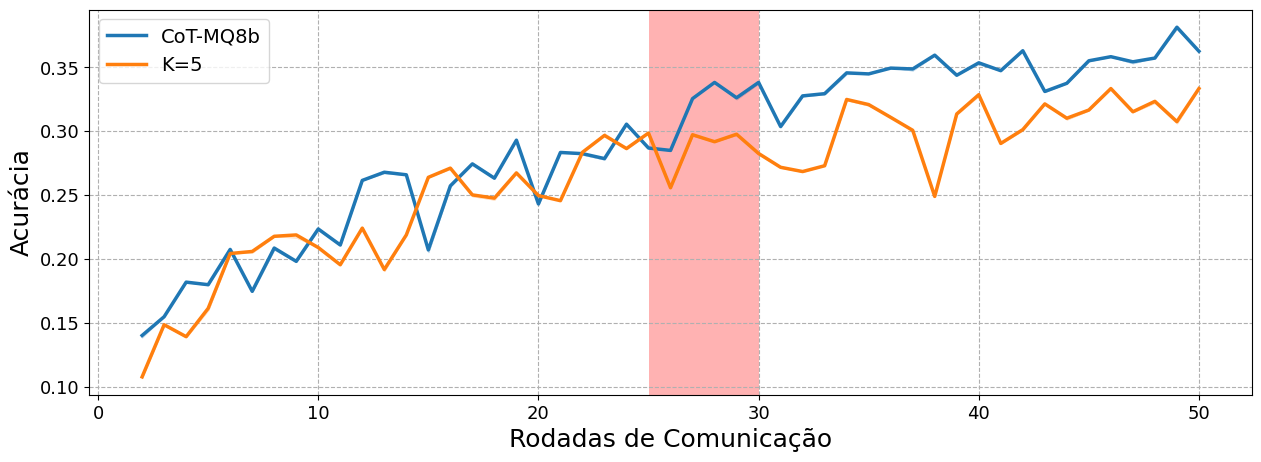

In [91]:
fig, ax = plt.subplots(figsize=(15, 5))
ax = sns.lineplot(df, x='round', y='eval_accuracy', hue='hue_column', errorbar=('ci', False), linewidth=2.5)
ax.axvspan(25, 30, facecolor='r', alpha=0.3)
ax.grid(True, linestyle='--')
ax.set_ylabel("Accuracy", fontsize=18)
ax.set_xlabel("Communication Rounds", fontsize=18)
ax.set_xticklabels(ax.get_xticklabels(), fontsize=13)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=13)
handles, labels_antigos = ax.get_legend_handles_labels()
novos_nomes = ["CoT-MQ8b", "K=5"]

ax.legend(
    handles=handles,
    labels=novos_nomes,
    fontsize=14,
)
plt.savefig("./imgs/convergencia.png", dpi=300)

In [ ]:
## "Round 25 is considered the middle of training... Therefore, I will keep K fixed at 5, allowing efficient exploration of the parameter space without overloading the network."

In [ ]:
## "Round 30 is considered intermediate... I set K=10 (40% of the network). This enables collecting diverse samples while reserving resources for future rounds."